<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Handwritten_Digit_Classification_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Persiapan Environment dan Eksplorasi Data

## Mengimpor Library

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist

print(f"Tensorflow Version: {tf.__version__}")

Tensorflow Version: 2.20.0


## Mengunduh dan Membagi Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data();

print(f"Training dataset size: {len(x_train)} images")
print(f"Testing dataset size: {len(x_test)} images")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training dataset size: 60000 images
Testing dataset size: 10000 images


## Memeriksa Ukuran dan Bentuk Data

In [3]:
print(f"Training images shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Min pixel value: {x_train.min()}")
print(f"Max pixel value: {x_train.max()}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Min pixel value: 0
Max pixel value: 255


## Menampilkan Gambar Angka (Visualisasi)

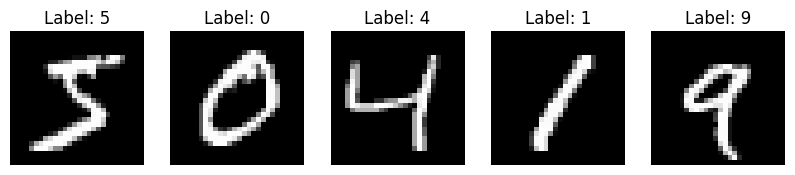

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for index in range(5):
  axes[index].imshow(x_train[index], cmap="gray")
  axes[index].set_title(f"Label: {y_train[index]}")
  axes[index].axis("off")
plt.show()

# Fase 2: Pra-pemrosesan Data (Data Preprocessing)

## Normalisasi Nilai Piksel (Pixel Normalization)

In [5]:
x_train_normalized = x_train / 255.0
x_test_normalized = x_test / 255.0

print(f"Original min value: {x_train.min()}, max value: {x_train.max()}")
print(f"Normalized min value: {x_train_normalized.min()}, max value: {x_train_normalized.max()}")

Original min value: 0, max value: 255
Normalized min value: 0.0, max value: 1.0


## Meratakan Bentuk Gambar (Data Reshaping / Flatening)

In [6]:
x_train_flattened = x_train_normalized.reshape(-1, 28 * 28)
x_test_flattened = x_test_normalized.reshape(-1, 28 * 28)

print(f"Original training shape: {x_train.shape}")
print(f"Flattened training shape: {x_train_flattened.shape}")

Original training shape: (60000, 28, 28)
Flattened training shape: (60000, 784)


## Memeriksa Format Label Target

In [7]:
print(f"Training labels data type: {y_train.dtype}")
print(f"First 10 training labels: {y_train[:10]}")
print(f"Unique digit classes: {set(y_train)}")

Training labels data type: uint8
First 10 training labels: [5 0 4 1 9 2 1 3 1 4]
Unique digit classes: {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)}


# Fase 3: Pembangunan dan Pelatihan Model Neural Network

## Membangun Arsitektur Model (Neural Network)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Menentukan Aturan Belajar

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compilation completed successfully")

Model compilation completed successfully


## Melatih Model (Training)

In [10]:
history = model.fit(
    x_train_flattened,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9249 - loss: 0.2579 - val_accuracy: 0.9640 - val_loss: 0.1165
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9677 - loss: 0.1055 - val_accuracy: 0.9775 - val_loss: 0.0826
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9777 - loss: 0.0719 - val_accuracy: 0.9772 - val_loss: 0.0793
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9823 - loss: 0.0553 - val_accuracy: 0.9743 - val_loss: 0.0871
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9855 - loss: 0.0449 - val_accuracy: 0.9780 - val_loss: 0.0777


# Fase 4: Evaluasi Model dan Pengujian Prediksi

## Menguji Akurasi Model pada Data Uji (Test Set)

In [11]:
test_loss, test_accuracy = model.evaluate(x_test_flattened, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 97.57%
Test Loss: 0.0827


## Visualisasi Grafik Performa Latihan vs Validasi

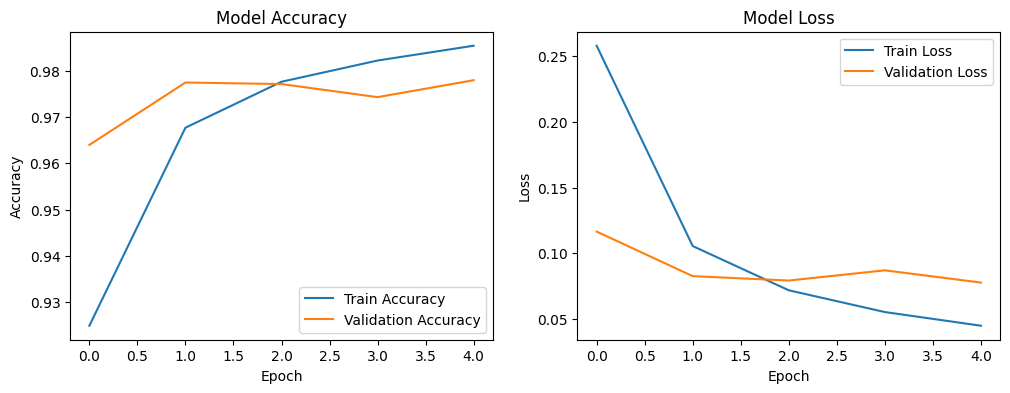

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()